# Facility Location Problem
Where should we open facilities (warehouses, charging stations, hospitals, distribution hubs, etc.) to minimize the total cost of serving customers? 
The decision is strategic because:
- Opening a facility involves a fixed cost
- Having fewer facilities increases transportation costs.
Therefore, the optimization must balance these two costs to achieve efficiency.

<!-- --- -->

## Business Problem
The company aims to build the best possible warehouse network to meet customer demand across multiple cities while minimizing total operational costs.

The company must decide:
1. **Strategic Decisions**:   At which locations, warehouses to be opened from a set of candidate locations
2. **Operational Decisions**: Which warehouse should serve which customers?

<!-- --- -->
### Goal
 **Minimize total logistics cost while maintaining service quality**. 
 
 The total cost includes
 1. Infrastructure cost (opening warehouses)
 2. Transportation cost (shipping goods)

<!-- --- -->

### Trade-off
Opening many warehouses closer to customer locations reduces transportation costs but increases operational costs. Meanwhile, a very small number of warehouses results in low operational costs but high transportation costs. Therefore, the decision must be made to balance these two costs effectively. 

<!-- --- -->
### Constraints
- Every customer must receive their demand.
- Each warehouse can handle only a limited volume within its capacity
- A warehouse must be opened before it can serve customers.

<!-- --- -->
### Applications of the problem:
1. Logistics (warehouse placement)
2. Evergy Systems (EV charging station planning)
3. Healthcare (Hospital placement)
4. Telecom (Cell tower placement)
5. Data infrastructure (Cloud data centers)



## Mathematical Formulation

#### Sets and Parameters
\begin{align*}
    \mathcal{F} &: \text{Set of facilities},\enspace i\in\mathcal{F} \\
    \mathcal{C} &: \text{Set of customers}, \enspace j\in\mathcal{C} \\
    s_i &: \text{Maximum capacity of the facility } i\\
    d_j &: \text{Demand of the customer }j \\
    f_i &: \text{Cost of opening the facility }i\\
    c_{ij} &: \text{Transporation cost from the facility }i \text{ to the customer }j 
\end{align*}

#### Decision Variables:
\begin{align*}
    y_i &= 
    \begin{cases}
        1, &\text{ if the facility is opened at the location }i\\
        0,&\text{ otherwise}
    \end{cases}\\
    x_{ij} &= \text{Quantities shipped from the facility }i \text{ to the customer }j
\end{align*}

#### Objective function
\begin{align*}
    \min\enspace \underbrace{\sum_{i\in\mathcal{F}} f_i~y_i}_{\text{Facility opening cost}}
    +\underbrace{\sum_{i\in\mathcal{F}}\sum_{j\in\mathcal{C}}c_{ij}~x_{ij}}_{\text{Shipping cost}}
\end{align*}
**Interpretation:** Our objective is to minimize the total cost, which includes the facility opening cost (the fixed cost we pay if we open a facility) and the transportation cost (the shipping cost from facility i to customer j).

#### Constraints:
1. Demand satisfaction constraints: \begin{align*} \sum_{i\in\mathcal{F}} x_{ij} = d_j~,\enspace \text{ for all customers }j \end{align*} **Interpretation:** Each customer must receive their demand.
2. Facility capacity constraint: \begin{align*} \sum_{j\in\mathcal{C}}x_{ij}\leq s_i~y_i,\enspace\forall~i\in\mathcal{F} \end{align*} **Interpretation:** A facility cannot ship more items than its maximum capacity.
3. Nonnegative shipments: \begin{align*} x_{ij}\geq 0,\enspace\forall~i,j \end{align*} **Interpretation:** Shipment cannot be negative.
4. Binary Decision variables: \begin{align*} y_i\in\{0,1\},\enspace \forall~i.\end{align*} **Interpretation:** It indicates whether the $i^{th}$ facility is open or not.

#### LP Relaxation


## Facility Location Problem v/s Transportation Problem 
The transportation problem is a linear program (LP) with continuous decision variables, and hence solvable in polynomial time.

In contrast, the facility location problem introduces binary decision variables to represent whether a facility is opened or not. This converts the problem into a mixed-integer linear program (MILP), leading to a combinatorial search space that grows exponentially with the number of facilities.


In [39]:
import pandas as pd

# Ensure full text is visible
pd.set_option('display.max_colwidth', None)

data = {
    "Parameter": [
        "Nature of decision variables",
        "Nature of the problem",
        "Feasible region",
        "Feasible set",
        "Solution approaches"
    ],
    
    "Transportation Problem": [
        "Continuous",
        "LP",
        "Convex",
        "Polyhedron",
        "Simplex"
    ],
    
    "Facility Location Problem": [
        "Binary variables",
        "MILP",
        "Nonconvex (Disconnected points)",
        "Combinatorial set (Searching among all 2^n combinations)",
        "Branch and Bound, Branch and Cut, Heuristics"
    ]
}

df = pd.DataFrame(data)

# Apply styling: left align everything + remove index
df.style.hide(axis="index") \
        .set_properties(**{'text-align': 'left'}) \
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'left')]}
        ])

Parameter,Transportation Problem,Facility Location Problem
Nature of decision variables,Continuous,Binary variables
Nature of the problem,LP,MILP
Feasible region,Convex,Nonconvex (Disconnected points)
Feasible set,Polyhedron,Combinatorial set (Searching among all 2^n combinations)
Solution approaches,Simplex,"Branch and Bound, Branch and Cut, Heuristics"


## Problem Data and Assumptions
For the facility location problem, we need to generate a geographic area that contains both facility and customer locations.

Customers can be generated either:
- randomly distributed, or  
- cluster-wise distributed to mimic real-world demand patterns 

Each customer has a specific demand.

Each facility has:
- a maximum capacity  
- a fixed opening cost  

Transportation cost is assumed to be proportional to the Euclidean distance between facilities and customers.

All parameters are synthetically generated in a reproducible manner.

Now we generate
1. Facility locations
2. Customer locations
3. Demand at each customer
4. Capacity of each facility
5. Opening cost of each facility
6. Transportation cost matrix


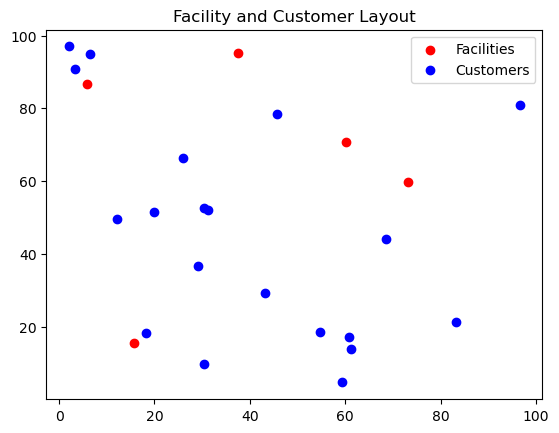

In [40]:
# 1. Importing the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 2. Generating facility and customer locations

np.random.seed(42)
n_facilities = 5
n_customers = 20

# generating the coordinates of each locations
facility_locations = np.random.uniform(0, 100, (n_facilities, 2))
customer_locations = np.random.uniform(0, 100, (n_customers, 2))

# Define labels (IMPORTANT)
facilities = [f"F{i}" for i in range(n_facilities)]
customers = [f"C{j}" for j in range(n_customers)]

# 3. Visualize the locations of facilities and customers
plt.scatter(facility_locations[:,0], facility_locations[:,1], c='red', label='Facilities')
plt.scatter(customer_locations[:,0], customer_locations[:,1], c='blue', label='Customers')
plt.legend()
plt.title("Facility and Customer Layout")
plt.show()

In [41]:
# 4. Generating the customer demand, customer capacity, and opening cost
demand = np.random.randint(5,20, size = n_customers)
capacity = np.random.randint(50,100, size = n_facilities)
opening_cost = np.random.randint(500,1000, size = n_facilities)

# 5. Generating a transportation cost matrix
from scipy.spatial.distance import cdist

distance_matrix = cdist(facility_locations, customer_locations, metric = "euclidean")
cost_per_km = 5
transportation_cost = cost_per_km * distance_matrix

# 6. Converting the parameters into dictionaries
opening_cost_dict = {facilities[i]: opening_cost[i] for i in range(n_facilities)}
capacity_dict = {facilities[i]: capacity[i] for i in range(n_facilities)}
demand_dict = {customers[j]:demand[j] for j in range(n_customers)}
transportation_cost_dict = {
    (facilities[i], customers[j]): transportation_cost[i][j]
    for i in range(n_facilities)
    for j in range(n_customers)
}

In [42]:
# Convert the parameter values to structured data and saving it

data = {
    "Facility Locations": facility_locations,
    "Customer Locations": customer_locations,
    "Demand": demand,
    "Capacity": capacity,
    "Fixed cost": opening_cost,
    "Transportation cost": transportation_cost
}

np.save("facility_location_problem_data.npy", data)

In [43]:
# OPTIONAL : If the customers are clustered like cities, then the demand is not uniform 
# from sklearn.datasets import make_blobs
# customer_locations, _ = make_blobs(n_samples=20, centers=3, cluster_std=8)


## From Business Problem to Optimization Code
To solve a business decision problem using optimization, the implementation is structured into 
1. Model construction
2. Solve the model
This separation ensures that the same optimization model can be reused across different scenarios while keeping the implementation clean, scalable, and easy to extend.

#### Model Construction
The mathematical structure of the business problem is translated into an optimization model using a model-building function.

This step defines:
- Decision variables  
- Objective function  
- Constraints  


In [44]:
import pyomo.environ as pyo

def build_facility_location_model(binary=True):
    # ===============================
    # Create the model
    # ===============================
    model = pyo.ConcreteModel()
    
    # ===============================
    # Sets
    # ===============================
    # facilities = [f"F{i}" for i in range(n_facilities)]
    # customers = [f"C{j}" for j in range(n_customers)]
    
    model.F = pyo.Set(initialize = facilities)
    model.C = pyo.Set(initialize = customers)
    
    # ===============================
    # Parameters
    # ===============================
    model.opening_cost = pyo.Param(model.F, initialize = opening_cost_dict)
    model.demand = pyo.Param(model.C, initialize = demand_dict)
    model.capacity = pyo.Param(model.F, initialize = capacity_dict)
    model.transportation_cost = pyo.Param(model.F, model.C, initialize = transportation_cost_dict)
    
    # ===============================
    # Decision Variables
    # ===============================
    model.x = pyo.Var(model.F, model.C, domain = pyo.NonNegativeReals)
    if binary:
        model.y = pyo.Var(model.F, domain = pyo.Binary)
    else:
        model.y = pyo.Var(model.F, domain = pyo.UnitInterval)
    
    # ===============================
    # Objective Function
    # ===============================
    def objective_rule(model):
        total_opening_cost = sum(model.opening_cost[i] * model.y[i] for i in model.F)
        total_transportation_cost = sum(model.transportation_cost[i,j] * model.x[i,j] for i in model.F for j in model.C)
        return total_opening_cost + total_transportation_cost
    
    model.obj = pyo.Objective(rule=objective_rule, sense=pyo.minimize)

    # ===============================
    # Constraints
    # ===============================
    # Demand satisfaction constraint
    def demand_satisfaction(model, j):
        return sum(model.x[i,j] for i in model.F) == model.demand[j] 
    
    model.demand_satis = pyo.Constraint(model.C, rule = demand_satisfaction)
    
    # Capacity constraint
    def max_capacity(model, i):
        return sum(model.x[i,j] for j in model.C) <= model.capacity[i] * model.y[i] 
    
    model.capacity_limits = pyo.Constraint(model.F, rule = max_capacity)

    return model
    


#### Solve and Analyze
The optimization model is solved using an appropriate solver, and the resulting decisions are extracted and presented in a readable format  to support interpretation and analysis.

In [45]:

# Solve the MILP model and print results
# ===============================

model = build_facility_location_model(binary=True)
solver = pyo.SolverFactory('cbc')
milp_results = solver.solve(model, tee=False)
milp_obj = pyo.value(milp_model.obj)
print("\n ========== RESULTS ==========\n")
print("Total cost=", milp_obj)
print("\n Distribution Table")
print("----------------------")
df_results = pd.DataFrame(index = model.F, columns = model.C)

for i in model.F:
    if pyo.value(model.y[i] < 0.5):
        for j in model.C:
            df_results.loc[i,j] = "Closed"
    else:
        for j in model.C:
            val = pyo.value(model.x[i,j])
            df_results.loc[i,j] = round(val, 2) if val > 1e-3 else 0
print(df_results)


 ========== RESULTS ==========

Total cost= 43284.87441303693

 Distribution Table
----------------------
        C0      C1      C2      C3      C4      C5      C6      C7      C8  \
F0  Closed  Closed  Closed  Closed  Closed  Closed  Closed  Closed  Closed   
F1       0     6.0       0       0       0    14.0       0       0       0   
F2       0       0    14.0       0     6.0       0    18.0       0       0   
F3    19.0       0       0       0       0       0       0       0    18.0   
F4       0       0       0    16.0       0       0       0     8.0       0   

        C9     C10     C11     C12     C13     C14     C15     C16     C17  \
F0  Closed  Closed  Closed  Closed  Closed  Closed  Closed  Closed  Closed   
F1       0    19.0       0    18.0       0    16.0       0       0       0   
F2    19.0       0       0       0    11.0       0     5.0       0       0   
F3       0       0    12.0       0       0       0     8.0    18.0       0   
F4       0       0       0       0

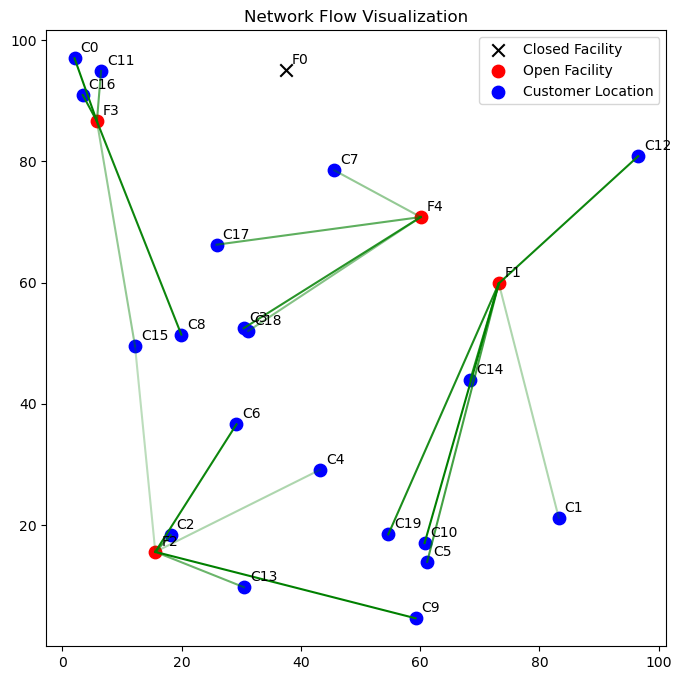

In [46]:
# Plotting the network flow graph

plt.figure(figsize=(8,8))

open_label_added = False
closed_label_added = False
customer_label_added = False

# Plot facilities and customers
for i, f in enumerate(model.F):
    if pyo.value(model.y[f]) > 0.5:
        plt.scatter(facility_locations[i,0], facility_locations[i,1], c='red', s=80,
                    label = 'Open Facility' if not open_label_added else "")
        open_label_added = True
    else:
        plt.scatter(facility_locations[i,0], facility_locations[i,1], c='black', s=80,
                    marker='x', label = "Closed Facility" if not closed_label_added else "")
        closed_label_added = True
for j, c in enumerate(model.C):
    plt.scatter(customer_locations[j,0], customer_locations[j,1], c='blue', s=80, 
                label = 'Customer Location' if not customer_label_added else "")
    customer_label_added = True

# Draw flow lines
max_flow = max(pyo.value(model.x[f, c]) for f in model.F for c in model.C)

for i, f in enumerate(model.F):
    for j,c in enumerate(model.C):
        flow = pyo.value(model.x[f,c])

        if flow > 1e-3:
            x_value = [facility_locations[i,0], customer_locations[j,0]]
            y_value = [facility_locations[i,1], customer_locations[j,1]]
            plt.plot(x_value, y_value, alpha=flow/max_flow, c='green')


# Label Facilities
for i, f in enumerate(model.F):
    plt.text(facility_locations[i,0]+1, facility_locations[i,1]+1, f)

for j, c in enumerate(model.C):
    plt.text(customer_locations[j,0]+1, customer_locations[j,1]+1, c)

plt.title("Network Flow Visualization")
plt.legend()
plt.show()

## LP Relaxation


To better understand the structure of the optimization problem, we analyze its **LP relaxation**.

In LP relaxation:
- Binary decision variables are relaxed to continuous values between 0 and 1  
- This removes combinatorial complexity and makes the problem easier to solve  

### Why is this useful?

- Provides a **lower bound** on the optimal MILP solution  
- Helps understand how “tight” the formulation is  
- Forms the basis of algorithms like **branch-and-bound**

However, LP relaxation may produce solutions that are **not physically implementable**.

In [47]:
lp_model=build_facility_location_model(binary=False)
lp_results=solver.solve(lp_model)
lp_obj=pyo.value(lp_model.obj)

print("MILP Optimal Value:", milp_obj)
print("LP Optimal Value:", lp_obj)
print("Percentage Deviation:", round((milp_obj-lp_obj)/(milp_obj)*100 , 2), "%")

MILP Optimal Value: 43284.87441303693
LP Optimal Value: 42868.57514671256
Percentage Deviation: 0.96 %


## Fractional Nature of LP Solution

In the LP relaxation, facility decision variables can take fractional values between 0 and 1.

For example:
- A value of 0.4 implies partially opening a facility  
- A value of 0.7 implies 70% activation of a facility  

### Why is this unrealistic?

In real-world systems:
- A warehouse is either opened or not  
- Partial opening is not physically meaningful  

### Consequences

- LP solutions underestimate the true cost  
- They cannot be directly implemented  
- They serve only as a **theoretical benchmark (lower bound)**  

This highlights the importance of solving the **MILP formulation**.

In [48]:
for i in lp_model.F:
    print(i, pyo.value(lp_model.y[i]))

F0 0.17910448
F1 0.9375
F2 1.0
F3 1.0
F4 0.44594595


# Extension 1: Scalable optimization for large-scale data analysis

To make the implementation reusable and scalable, we design a modular pipeline that separates the workflow into distinct stages.

Instead of hardcoding data and model structure for a fixed problem size, the system is built to handle **any number of facilities and customers**.

The implementation consists of the following steps:

1. **Data Generation**  
   Automatically generates synthetic problem data (locations, demand, capacity, costs) based on input size  

2. **Model Construction**  
   Builds the optimization model using Pyomo by defining:
   - decision variables  
   - objective function  
   - constraints  

3. **Model Solution**  
   Solves the model using an optimization solver (e.g., CBC, CPLEX)

4. **Result Extraction**  
   Extracts and presents key outputs such as:
   - selected facilities  
   - total cost  

<!-- --- -->

### Objective of this Design

- Ensure **scalability** across different problem sizes  
- Improve **code reusability and clarity**  
- Enable easy extension to more complex models (stochastic, multi-period, etc.)

<!-- --- -->

### Usage

The entire workflow is executed through a single function:

```python
run_pipeline(n_facilities, n_customers)

In [49]:
# Generate data

import numpy as np
from scipy.spatial.distance import cdist

def generate_data(n_facilities, n_customers, seed=42):
    np.random.seed(seed)
    
    # Labels
    facilities = [f"F{i}" for i in range(n_facilities)]
    customers = [f"C{j}" for j in range(n_customers)]
    
    # Locations
    facility_locations = np.random.uniform(0, 100, (n_facilities, 2))
    customer_locations = np.random.uniform(0, 100, (n_customers, 2))
    
    # Demand & capacity
    demand = np.random.randint(5, 20, size=n_customers)
    capacity = np.random.randint(50, 100, size=n_facilities)
    
    # Ensure feasibility
    if capacity.sum() < demand.sum():
        scale_factor = demand.sum() / capacity.sum()
        capacity = (capacity * scale_factor * 1.2).astype(int)
    
    # Opening cost
    opening_cost = np.random.randint(500, 1000, size=n_facilities)
    
    # Transport cost
    distance_matrix = cdist(facility_locations, customer_locations)
    cost_per_km = 5
    transportation_cost = cost_per_km * distance_matrix
    
    # Convert to dictionaries
    opening_cost_dict = {facilities[i]: opening_cost[i] for i in range(n_facilities)}
    capacity_dict = {facilities[i]: capacity[i] for i in range(n_facilities)}
    demand_dict = {customers[j]: demand[j] for j in range(n_customers)}
    
    transportation_cost_dict = {
        (facilities[i], customers[j]): transportation_cost[i][j]
        for i in range(n_facilities)
        for j in range(n_customers)
    }
    
    return {
        "facilities": facilities,
        "customers": customers,
        "facility_locations": facility_locations,
        "customer_locations": customer_locations,
        "opening_cost": opening_cost_dict,
        "capacity": capacity_dict,
        "demand": demand_dict,
        "transport_cost": transportation_cost_dict
    }

In [50]:
# Build the pyomo model

import pyomo.environ as pyo

def build_model(data, binary=True):
    model = pyo.ConcreteModel()
    
    model.F = pyo.Set(initialize=data["facilities"])
    model.C = pyo.Set(initialize=data["customers"])
    
    model.opening_cost = pyo.Param(model.F, initialize=data["opening_cost"])
    model.capacity = pyo.Param(model.F, initialize=data["capacity"])
    model.demand = pyo.Param(model.C, initialize=data["demand"])
    model.transport_cost = pyo.Param(model.F, model.C, initialize=data["transport_cost"])
    
    model.x = pyo.Var(model.F, model.C, domain=pyo.NonNegativeReals)
    
    if binary:
        model.y = pyo.Var(model.F, domain=pyo.Binary)
    else:
        model.y = pyo.Var(model.F, domain=pyo.UnitInterval)
    
    # Objective
    def obj_rule(model):
        return (
            sum(model.opening_cost[i] * model.y[i] for i in model.F)
            +
            sum(model.transport_cost[i, j] * model.x[i, j]
                for i in model.F for j in model.C)
        )
    model.obj = pyo.Objective(rule=obj_rule, sense=pyo.minimize)
    
    # Demand constraint
    def demand_rule(model, j):
        return sum(model.x[i, j] for i in model.F) == model.demand[j]
    model.demand_constraint = pyo.Constraint(model.C, rule=demand_rule)
    
    # Capacity constraint
    def capacity_rule(model, i):
        return sum(model.x[i, j] for j in model.C) <= model.capacity[i] * model.y[i]
    model.capacity_constraint = pyo.Constraint(model.F, rule=capacity_rule)
    
    return model

In [51]:
# Solve the  model
def solve_model(model, solver_name='cbc'):
    solver = pyo.SolverFactory(solver_name)
    results = solver.solve(model, tee=False)
    
    return results

In [52]:
# Extract the results
def extract_results(model):
    open_facilities = [i for i in model.F if pyo.value(model.y[i]) > 0.5]
    total_cost = pyo.value(model.obj)
    
    return open_facilities, total_cost

In [53]:
def run_pipeline(n_facilities, n_customers, solver='cbc'):
    
    # Step 1: Generate data
    data = generate_data(n_facilities, n_customers)
    
    # Step 2: Build MILP model
    model = build_model(data, binary=True)
    
    # Step 3: Solve
    solve_model(model, solver)
    
    # Step 4: Extract results
    open_facilities, total_cost = extract_results(model)
    
    print("Number of Facilities:", n_facilities)
    print("Number of Customers:", n_customers)
    print("Open Facilities:", open_facilities)
    print("Total Cost:", total_cost)
    
    return data, model

In [54]:
data, model = run_pipeline(20, 100)

Number of Facilities: 20
Number of Customers: 100
Open Facilities: ['F0', 'F1', 'F2', 'F3', 'F4', 'F6', 'F7', 'F8', 'F9', 'F11', 'F12', 'F13', 'F14', 'F15', 'F16', 'F17', 'F18', 'F19']
Total Cost: 78121.18914290755


## Key Takeaways

- Facility location is a **mixed-integer optimization problem** combining strategic and operational decisions  
- There is a critical **trade-off between infrastructure cost and transportation cost**  
- LP relaxation provides useful insights but yields **non-implementable fractional solutions**  
- MILP ensures **realistic and actionable decisions**  

---

### Scalability and Extensions

The current model can be extended to:

- Stochastic demand modeling  
- Robust optimization under uncertainty  
- Integration with routing problems (VRP)  
- Multi-period planning  

---
